# Twitch A/B Test Analysis: Improving Subscription Conversion with Contextual Value Microcopy

#### Contents
1. Product Context & Hypothesis
2. Experiment Design
3. Data Overview
4. Data Validation & Sanity Checks
5. Primary Metric
6. Secondary Metrics 
7. Guardrails
8. Launch Decision & Recommendations
9. Post-decision Insights: Segmentation Analysis
10. Next Experiments

#### TL;DR

We tested contextual value microcopy under the Subscribe CTA to improve subscription conversion. The treatment increased paid conversion, with consistent improvements across the funnel and no meaningful guardrail impact. 

Launch decision: we recommend shipping to 100% of users.

# 1. Product Context & Hypothesis

#### Product context

Twitch is a popular live streaming platform focused on video games, esports, and creative content. While best known for gaming, it has expanded to include music, art, podcasts, "Just Chatting," and other creator-led experiences.

Streamers monetize through advertisements, viewer subscriptions, and virtual currency (Bits).

Twitch is available across web, mobile, and gaming console platforms.

#### User problem

Viewers often hesitate to subscribe because:
- The value of subscribing is abstract or unclear
- Benefits (ad-free, perks, creator support) are not top-of-mind at the moment of decision
- Different viewers care about different aspects of the subscription value

This creates friction at a high-intent decision point.

#### Business goal

Increase paid subscription growth while preserving:
- viewer engagement (watch time, chat activity)
- long-term trust (avoid accidental or regretful purchases)

This is a monetization-UX tradeoff, not a pursuit of pure growth at all costs.

#### Product idea

Introduce contextual value microcopy under the Subscribe CTA that highlights the most relevant benefit for each viewer at the moment they encounter the CTA.

Example value framings (abstracted into categories):
- Ad-free viewing
- Loyalty / relationship (“you’ve watched a lot”)
- Perks (emotes, badges)
- Creator support (fallback messaging)

#### Core hypothesis

Showing contextual value microcopy under the Subscribe CTA will reduce uncertainty at the decision moment and increase paid subscription conversion, without harming engagement.

This is a behavioral framing intervention, not a change to pricing or eligibility.

# 2. Experiment Design

This experiment evaluates whether contextual value microcopy under the Subscribe CTA increases paid subscription conversion without negatively impacting engagement or monetization guardrails.

#### Target population

Target population:
- Logged-in Twitch viewers
- Not currently subscribed to the channel they are viewing
- Exposed to the Subscribe CTA on a channel page or live stream
- Includes both desktop and mobile users

We do not restrict to high-intent viewers a priori to ensure results generalize to the broader viewer population.

#### Unit of randomization

Unit of randomization: user-level randomization
- Each user is assigned to control or treatment once
- Users see a consistent experience across sessions and channels

Rationale:
- The Subscribe CTA is a global UI pattern
- Avoids users seeing inconsistent experiences across channels
- Simplifies interpretation and mirrors how real UI experiments ship


#### Eligibility & exposure

Users are eligible if they:
- Are logged in
- Are not subscribed to the current channel

Exposure occurs when a stream/channel page renders the Subscribe CTA.

Outcome window: same-day relative to exposure

#### Variants (control vs. treatment)

Variants:
- **Control**: Existing Subscribe CTA (no contextual microcopy)

- **Treatment**: Subscribe CTA + contextual value microcopy

Microcopy category is selected deterministically in treatment using pre-exposure signals:
1. Ads seen in last 24h → Ad-free viewing
2.	High recent watch time → Loyalty framing
3.	Follows / chats → Perks framing
4.	Else → Creator support

#### Traffic allocation 

Traffic allocation: **50/50 split** between control and treatment

Rationale:
- Maximizes statistical power for a fixed sample size
- Standard for A/B tests with symmetric risk
- Simplifies interpretation of results

#### Primary metric

The primary metric we selected is:
- Paid subscription conversion rate (same-day)


Rationale:
- Directly reflects monetization impact
- Aligns with the business goal of increasing paid subscriptions
- Avoids confounding from Prime subscriptions (which do not generate incremental revenue)


#### Secondary metrics

The secondary metrics we selected are: 
- Clicked subscribe (rate per exposure)
- Checkout started (rate per exposure)
- Prime subscription conversion rate
- Any subscription (paid + Prime) conversion rate

Rationale:
- "Click → checkout → subscription" captures the full funnel
- Prime vs. paid helps distinguish monetization vs. value recognition
- Any-sub captures overall subscription intent and provides a creator-centric view of conversion (since both Prime and paid subs help them)


#### Guardrails

The guardrails we selected are: 
- Watch time per exposed user
- Chat messages per user
- Ad impressions per user
- Low-intent paid proxy (paid + very low watch time + no chat)

Rationale:
- Watch time is a core engagement metric; aggressive monetization can reduce viewing; microcopy might distract or annoy users
- Chat activity is a community guardrail: Twitch's value is interactive engagement
- Ad impressions is a monetization side-effect guardrail: paid subs reduce ads, so a subscription lift could cannibalize ad revenue
- Low-intent proxy safeguards against impulsive or regretful purchases; CTA microcopy could induce impulsive purchases; those often show up as: fast cancellations, refunds, chargebacks. We don’t have refunds, so we use a proxy

#### Power analysis


- **Power**: 80%

- **Statistical significance (α)**: 0.05 (two-sided)

- **Baseline paid CVR**: 0.50%

- **Target MDE**: +10% relative lift (0.50% → 0.55%)

- **Required sample size**: ~327k users per arm

Traffic assumptions: Daily eligible exposures: ~100k exposed users/day

#### Planned duration

Minimum duration: ~7 days (expecting 50k users per arm per day)

Planned duration: 14 days

Rationale:
- Covers two full weekly cycles
- Buffers traffic and logging noise
- Stabilizes low base-rate metrics
- Aligns with standard experimentation cadence


#### Ramp-up plan

1. Internal QA / canary (0–1%).

2. Gradual ramp (5–10%).

3. Full allocation (50/50).

4. Hold until power is reached.

Gradual ramping ensures:
- instrumentation correctness
- correct microcopy assignment
- early detection of guardrail regressions

# 3. Data Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data sources

In [2]:
exposures = pd.read_csv("../simulated_twitch_dataset/twitch_ab_exposures.csv.gz")
funnel = pd.read_csv("../simulated_twitch_dataset/twitch_ab_funnel_outcomes.csv.gz")

We use two datasets representing different stages of the experiment: 
- **exposures** table: contains treatment assignment and pre-exposure context (who was exposed, behavior prior to seeing the CTA, and assigned variant)
- **funnel** outcomes table: contains post-exposure behavior (clicks, subscriptions, engagement, and guardrail metrics)

Our analysis requires combining pre-exposure inputs with post-exposure outcomes.

### Data overview & initial inspection

Checking row & column counts

In [3]:
exposures.shape

(1400000, 11)

Each row in the exposures table represents a single exposure of a user to the Subscribe CTA.

In [4]:
funnel.shape

(1400000, 11)

**Preview of tables**

In [5]:
exposures.head()

,user_id,channel_id,experiment_variant,exposure_date,microcopy_category,ads_seen_24h,watch_minutes_7d,follows_channel,chatted_recently,device_type,is_prime_eligible
0,41822,1,control,2026-02-01,NaN,1,44.018723,False,False,mobile,True
1,324232,3,control,2026-02-01,NaN,3,39.979263,False,False,mobile,False
2,144525,1368,control,2026-02-01,NaN,8,200.862170,True,False,mobile,True
3,238568,5053,treatment,2026-02-01,ad_free,6,155.679890,False,False,desktop,False
4,259096,21,treatment,2026-02-01,ad_free,7,237.156540,True,False,mobile,True


In [6]:
funnel.head()

,user_id,channel_id,exposure_date,clicked_subscribe,checkout_started,subscription_type,revenue,watch_time_minutes,chat_messages,ad_impressions,low_intent_paid_proxy
0,41822,1,2026-02-01,False,False,none,0.0,18.807817,2,0,False
1,324232,3,2026-02-01,False,False,none,0.0,50.527860,3,3,False
2,144525,1368,2026-02-01,False,False,none,0.0,204.369920,17,20,False
3,238568,5053,2026-02-01,False,False,none,0.0,38.658740,5,4,False
4,259096,21,2026-02-01,False,False,none,0.0,28.618477,5,5,False


**Checking variant split**

In [7]:
exposures["experiment_variant"].value_counts(normalize=True)

experiment_variant
treatment    0.500854
control      0.499146
Name: proportion, dtype: float64

The experiment is evenly split between control and treatment (~50/50), as expected.

**Uniqueness checks (users and channels)**

In [8]:
funnel[["user_id", "channel_id"]].nunique()

user_id       346689
channel_id      6000
dtype: int64

In [9]:
exposures["user_id"].nunique()

346689

**Missing values check**

In [10]:
exposures.isna().sum()

user_id                    0
channel_id                 0
experiment_variant         0
exposure_date              0
microcopy_category    698805
ads_seen_24h               0
watch_minutes_7d           0
follows_channel            0
chatted_recently           0
device_type                0
is_prime_eligible          0
dtype: int64

Approximately half of microcopy_category values are null, which is expected as control users are not assigned a microcopy category.

In [11]:
funnel.isna().sum()

user_id                  0
channel_id               0
exposure_date            0
clicked_subscribe        0
checkout_started         0
subscription_type        0
revenue                  0
watch_time_minutes       0
chat_messages            0
ad_impressions           0
low_intent_paid_proxy    0
dtype: int64

**Feature sanity checks**

Distribution of exposures:

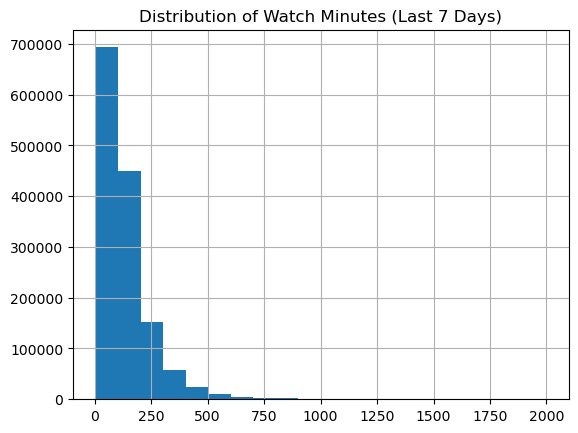

In [12]:
exposures["watch_minutes_7d"].hist(bins=20)
plt.title("Distribution of Watch Minutes (Last 7 Days)")
plt.show()

Watch time is highly right-skewed, with most users exhibiting low to moderate engagement and a long tail of highly engaged viewers.

Distribution of ads seen:

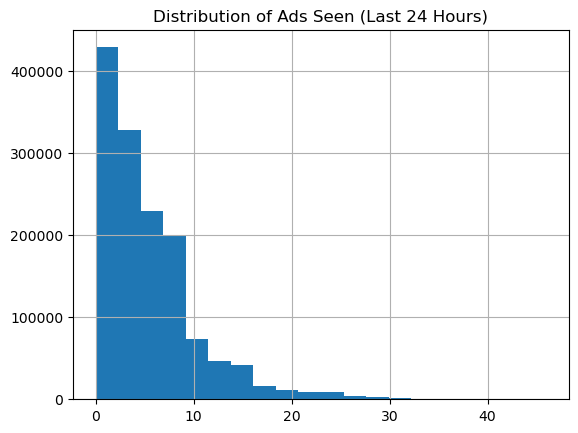

In [13]:
exposures["ads_seen_24h"].hist(bins=20)
plt.title("Distribution of Ads Seen (Last 24 Hours)")
plt.show()

Ads seen in the last 24 hours is right-skewed but relatively concentrated, with most users experiencing low to moderate ad exposure.

In [14]:
exposures["microcopy_category"].value_counts(normalize=True)

microcopy_category
creator_support    0.370418
ad_free            0.369625
perks              0.147331
loyalty            0.112626
Name: proportion, dtype: float64

Microcopy categories are reasonably balanced, with no single category dominating, indicating that the targeting logic distributes users across multiple value propositions.

In [15]:
print("Exposure date range:", exposures["exposure_date"].min(), "to", exposures["exposure_date"].max())

Exposure date range: 2026-02-01 to 2026-02-14


The exposure window spans 14 days, covering a full two-week period consistent with the planned experiment duration.

### Constructing the analysis dataset

To analyze treatment effects, we join exposures (inputs) with funnel outcomes (outputs).

Because users can have multiple exposures per day per channel, (user_id, channel_id, exposure_date) is not unique. We therefore construct a row-level identifier (exposure_id) and perform a one-to-one merge.

The resulting dataset is at the exposure level, with each row linking pre-exposure context and treatment assignment to post-exposure outcomes. Join correctness and data integrity are validated in the next section.

In [16]:
# Reset indices and create stable row-level identifiers
exposures_reset = exposures.reset_index(drop=True)
funnel_reset = funnel.reset_index(drop=True)

exposures_reset["exposure_id"] = exposures_reset.index
funnel_reset["exposure_id"] = funnel_reset.index

# Merge into a single analysis dataset
df = exposures_reset.merge(
    funnel_reset,
    on="exposure_id",
    how="inner",
    validate="one_to_one",
    suffixes=("", "_funnel")
)

This resulting dataset will be used for all downstream analysis.

**Post-join checks**

In [17]:
print("Joined dataset shape:", df.shape)

Joined dataset shape: (1400000, 23)


In [18]:
postjoin_summary = pd.DataFrame({
    "dataset": ["exposures", "funnel", "joined_analysis_df"],
    "rows": [len(exposures), len(funnel), len(df)],
    "unique_users": [
        exposures["user_id"].nunique(),
        funnel["user_id"].nunique(),
        df["user_id"].nunique()
    ]
})

display(postjoin_summary)

,dataset,rows,unique_users
0,exposures,1400000,346689
1,funnel,1400000,346689
2,joined_analysis_df,1400000,346689


### Data overview summary

The dataset consists of exposure-level observations linking treatment assignment and pre-exposure context to post-exposure outcomes. 

The experiment is evenly split between control and treatment, with no major data quality issues observed. 

Key features exhibit expected distributions, including a right-skewed engagement profile and varied ad exposure, while microcopy categories are appropriately assigned within the treatment group. 

The data spans a full two-week period, aligning with the planned experiment duration and providing sufficient coverage for analysis.

# 4. Data Validation & Sanity Checks

Before analyzing treatment effects, we validate data integrity, randomization, treatment delivery, and overall experiment health.

Specifically, we perform the following checks:
- **Join validation**: ensure exposures and outcomes are correctly merged at the exposure level
- **Randomization checks**: confirm traffic allocation and user-level assignment stability
- **Pre-exposure covariate balance**: verify treatment and control are comparable before exposure
- **Treatment delivery checks**: confirm the treatment was applied correctly and consistently

### Join validation

We validate that the exposures and funnel tables were correctly merged into a one-to-one, exposure-level dataset.

Specifically, we check for:
- No row loss  
- No duplication of rows 
- Correct key alignment  
- True one-to-one mapping


**Row count consistency**

We verify row count consistency to ensure no row loss and no duplication.

In [19]:
assert len(df) == len(exposures) == len(funnel)

**One-to-one merge**

The merge is enforced as one-to-one using `validate="one_to_one"`. This guarantees that each exposure is matched to exactly one outcome record.

**Key alignment checks**

These checks confirm that exposure-level keys align correctly between the two tables after the merge.

In [20]:
print("Key alignment checks:")
print("  user_id:", (df["user_id"] == df["user_id_funnel"]).all())
print("  channel_id:", (df["channel_id"] == df["channel_id_funnel"]).all())
print("  exposure_date:", (df["exposure_date"] == df["exposure_date_funnel"]).all())

Key alignment checks:
  user_id: True
  channel_id: True
  exposure_date: True


**Mismatch rates**

While the key alignment checks give us a binary value on whether all keys match, mismatch rates quantify how many don't match.

Mismatch rates should be zero.

In [21]:
mismatched_users = df["user_id"] != df["user_id_funnel"]
mismatched_channels = df["channel_id"] != df["channel_id_funnel"]
mismatched_dates = df["exposure_date"] != df["exposure_date_funnel"]

print("Mismatch rates:")
print(" user_id:", mismatched_users.mean())
print(" channel_id:", mismatched_channels.mean())
print(" exposure_date:", mismatched_dates.mean())

Mismatch rates:
 user_id: 0.0
 channel_id: 0.0
 exposure_date: 0.0


**Drop duplicate columns after validation**

In [22]:
df = df.drop(columns=["user_id_funnel", "channel_id_funnel", "exposure_date_funnel"])

**Summary**

All join validation checks pass: row counts are preserved, key fields align perfectly, and mismatch rates across keys are zero, confirming a correct one-to-one merge.

### Randomization checks

Randomization checks confirm that treatment assignment is correctly implemented and stable at the user level.

**Traffic allocation**

In [23]:
df["experiment_variant"].value_counts(normalize=True)

experiment_variant
treatment    0.500854
control      0.499146
Name: proportion, dtype: float64

Traffic allocation is balanced between control (49.9%) and treatment (50.1%), consistent with the intended 50/50 split.

**User-level assignment stability**

Because this is user-level randomization, each user should appear in only one variant.

In [24]:
df.groupby("user_id")["experiment_variant"].nunique().value_counts()

experiment_variant
1    346689
Name: count, dtype: int64

Each user is assigned to exactly one variant, confirming stable user-level randomization with no cross-variant contamination.

**Summary**

Traffic allocation is balanced and each user is consistently assigned to a single variant, confirming correct and stable randomization.

### Pre-exposure covariate balance

We verify that randomization produced comparable groups by examining pre-exposure covariates that should not be affected by treatment.

**Covariate balance (means)**

In [25]:
balance_cols = [
    "watch_minutes_7d",
    "ads_seen_24h",
    "follows_channel",
    "chatted_recently",
    "is_prime_eligible"
]

df.groupby("experiment_variant")[balance_cols].mean()

,watch_minutes_7d,ads_seen_24h,follows_channel,chatted_recently,is_prime_eligible
experiment_variant,,,,,
control,136.785795,5.416148,0.263119,0.180199,0.623394
treatment,137.170306,5.429070,0.263379,0.180555,0.618411


Pre-exposure covariates are well balanced between control and treatment, with no meaningful differences across engagement, ad exposure, or user characteristics. This confirms that randomization produced comparable groups prior to treatment.

**Device mix**

In [26]:
pd.crosstab(
    df["experiment_variant"],
    df["device_type"],
    normalize="index"
)

device_type,desktop,mobile
experiment_variant,,
control,0.548516,0.451484
treatment,0.548977,0.451023


Device mix is consistent across control and treatment, indicating no imbalance in platform distribution that could confound results.

**Summary**

Covariate differences are negligible, suggesting no systematic bias between treatment and control groups.

### Treatment delivery

We verify that the treatment is delivered correctly and only to the intended users.

Specifically, we check that:
- Control users do not receive microcopy  
- Treatment users receive microcopy  
- Microcopy categories are assigned as intended  

**Control integrity**

This check ensures that control users were not exposed to treatment content.

In [27]:
df.loc[df.experiment_variant == "control", "microcopy_category"].value_counts()

Series([], Name: count, dtype: int64)

All control exposures have a null microcopy_category, confirming that no treatment content leaked into the control variant.

**Treatment coverage**

This check verifies that all treatment exposures received microcopy and that categories are reasonably distributed.

In [28]:
df.loc[df.experiment_variant == "treatment", "microcopy_category"].value_counts(normalize=True)

microcopy_category
creator_support    0.370418
ad_free            0.369625
perks              0.147331
loyalty            0.112626
Name: proportion, dtype: float64

All treatment exposures receive microcopy, with a balanced distribution across categories, indicating consistent treatment delivery.

**Category assignment plausibility**

This check verifies that microcopy categories align with the intended targeting logic based on pre-exposure behavior.

In [29]:
df.groupby("microcopy_category")[[
    "watch_minutes_7d",
    "ads_seen_24h",
    "follows_channel",
    "chatted_recently"
]].mean()

,watch_minutes_7d,ads_seen_24h,follows_channel,chatted_recently
microcopy_category,,,,
ad_free,230.562575,10.256819,0.342339,0.234707
creator_support,64.953924,2.284028,0.000000,0.000000
loyalty,155.235984,3.839186,0.287427,0.203120
perks,70.622758,2.439801,0.709084,0.481395


Microcopy categories exhibit expected differences in pre-exposure behavior (e.g., higher ad exposure for the "ad-free" category, stronger engagement for the "loyalty"/"perks" categories), confirming that assignment logic behaves as intended.

**Summary**

Treatment is delivered correctly, with no leakage into control and appropriate assignment of microcopy across treatment exposures.

### Summary of sanity checks

- **Data integrity**: Exposure and outcome tables were successfully joined into a single exposure-level dataset with one row per Subscribe CTA exposure.

- **Randomization**: Traffic is evenly split (~50/50), and each user is assigned to exactly one variant, confirming stable user-level randomization.

- **Covariate balance**: Pre-exposure covariates (recent watch time, ad exposure, follow/chat behavior, Prime eligibility, device type) are well balanced across variants, with no meaningful differences.

- **Treatment delivery**: No control exposures received microcopy, and all treatment exposures received microcopy with a plausible distribution across value categories.

- **Assignment logic**: Microcopy categories align with expected pre-exposure behavior, confirming that contextual assignment logic behaved as intended.

**Conclusion**: All pre-analysis validation and sanity checks pass. Data integrity, randomization, and treatment delivery are validated. The data is suitable for causal analysis of the treatment effect on subscription conversion.

# 5. Primary Metric

### Defining the primary metric

The primary metric is **same-day paid subscription conversion rate**, defined as the proportion of exposures that result in a paid subscription on the same day.

This metric directly captures the business objective of increasing paid subscriptions and aligns with the moment of exposure to the Subscribe CTA.

In order to define our primary metric, in the dataset, we'll create a binary version of our subscription_type column:
- Paid conversion = 1 if `subscription_type == "paid"`, else 0.

In [30]:
df["paid_sub"] = (df["subscription_type"] == "paid").astype(int)

Next, we evaluate the impact of the treatment on paid subscription conversion using both direct rate comparisons and statistical inference.

### Estimating lift for primary metric

We compute conversion rates by variant to estimate the magnitude of the effect.

In [31]:
paid_cvr = (
    df.groupby("experiment_variant")
      .agg(
          exposures=("paid_sub", "size"),
          paid_subs=("paid_sub", "sum"),
          paid_cvr=("paid_sub", "mean")
      )
)

paid_cvr

,exposures,paid_subs,paid_cvr
experiment_variant,,,
control,698805,3494,0.005000
treatment,701195,3857,0.005501


Results:
- **Control conversion rate**: 0.50%
- **Treatment conversion rate**: 0.55%

This corresponds to:
- **Absolute lift**: +0.050 percentage points
- **Relative lift**: +10.0%

The treatment increases paid subscription conversion by approximately 10% relative, representing a meaningful improvement given the low baseline conversion rate.

**Summary**

The treatment increases paid subscription conversion by **+0.050 percentage points (+10.0% relative lift)**. 

While the absolute effect is small in percentage-point terms, this represents a meaningful improvement given the low baseline conversion rate and large scale of exposure. With ~700k exposures per group, this translates to a substantial increase in total paid subscriptions.

### Statistical inference for primary metric

To assess whether the observed difference in conversion rates is statistically significant, we conduct a **two-proportion z-test**. This test evaluates whether the difference between treatment and control conversion rates is larger than would be expected due to random variation.

We also construct a **95% confidence interval** for the difference in conversion rates (lift) using the **Newcombe (Wilson)** method, which provides a more accurate interval for proportions than the standard normal approximation.

In [32]:
from scipy import stats

In [33]:
def two_prop_ztest(x_c, n_c, x_t, n_t):
    p_c = x_c / n_c
    p_t = x_t / n_t
    diff = p_t - p_c

    p_pool = (x_c + x_t) / (n_c + n_t)
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n_c + 1 / n_t))

    if se_pool == 0:
        return np.nan, np.nan

    z = diff / se_pool
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

In [34]:
def wilson_ci(x, n, alpha=0.05):
    """
    Wilson score interval for a single proportion.
    Returns (lower, upper).
    """
    z = stats.norm.ppf(1 - alpha/2)
    p = x / n
    denom = 1 + (z**2)/n
    center = (p + (z**2)/(2*n)) / denom
    half = (z * np.sqrt((p*(1-p)/n) + (z**2)/(4*n**2))) / denom
    return center - half, center + half

def newcombe_diff_ci(x_c, n_c, x_t, n_t, alpha=0.05):
    c_lo, c_hi = wilson_ci(x_c, n_c, alpha)
    t_lo, t_hi = wilson_ci(x_t, n_t, alpha)
    return (t_lo - c_hi), (t_hi - c_lo)

In [35]:
# ----------------------------
# 1) Aggregate counts + rates
# ----------------------------
agg = (
    df.groupby("experiment_variant")["paid_sub"]
      .agg(paid_subs="sum", n="count")
)

x_c, n_c = int(agg.loc["control", "paid_subs"]), int(agg.loc["control", "n"])
x_t, n_t = int(agg.loc["treatment", "paid_subs"]), int(agg.loc["treatment", "n"])

p_c = x_c / n_c
p_t = x_t / n_t

# Effect sizes
diff = p_t - p_c          # absolute lift in probability units
diff_pp = diff * 100      # absolute lift in percentage points
rel = diff / p_c          # relative lift
rel_pct = rel * 100

# ----------------------------
# 2) Statistical inference
# ----------------------------
z_stat, p_value = two_prop_ztest(x_c, n_c, x_t, n_t)
ci_low, ci_high = newcombe_diff_ci(x_c, n_c, x_t, n_t)

# ----------------------------
# 3) Present results
# ----------------------------
results = pd.DataFrame({
    "Control paid CVR": [f"{p_c*100:.3f}%"],
    "Treatment paid CVR": [f"{p_t*100:.3f}%"],
    "Absolute lift": [f"{diff_pp:.3f}pp"],
    "95% CI for lift (pp)": [f"[{ci_low*100:.3f}pp, {ci_high*100:.3f}pp]"],
    "Relative lift": [f"{rel_pct:.1f}%"],
    "p-value": ["< 0.001" if p_value < 0.001 else f"{p_value:.3f}"]
})

results

,Control paid CVR,Treatment paid CVR,Absolute lift,95% CI for lift (pp),Relative lift,p-value
0,0.500%,0.550%,0.050pp,"[0.016pp, 0.084pp]",10.0%,< 0.001


### Interpreting & summarizing primary metric results

The treatment increases paid subscription conversion by +0.050 percentage points (**+10.0% relative lift**), from 0.50% to 0.55%.

This effect is statistically significant (**p < 0.001**), indicating that the observed improvement is unlikely to be due to random variation.

The 95% confidence interval for the lift, **[+0.016pp, +0.084pp]**, excludes zero, providing further evidence of a positive treatment effect.

While the absolute lift is small in percentage-point terms, it is meaningful given the low baseline conversion rate and large scale of exposure. At scale, even small improvements in conversion rate can generate significant incremental revenue.

Overall, the evidence indicates that contextual value microcopy causally improves paid subscription conversion.

# 6. Secondary Metrics

### Defining secondary metrics

In addition to the primary metric, we analyze secondary metrics to understand where in the funnel the treatment has impact and how it affects the composition of subscriptions.

The secondary metrics are:
- **clicked_subscribe**: whether the user clicks the Subscribe CTA
- **checkout_started**: whether the user begins the checkout flow
- **any_sub**: whether the user subscribes (paid or Prime)
- **prime_sub**: whether the user subscribes using Prime

To construct these metrics:

In [36]:
df["prime_sub"] = (df["subscription_type"] == "prime").astype(int)

In [37]:
df["any_sub"] = ((df["prime_sub"] == 1) | (df["paid_sub"] == 1)).astype(int)

We verify logical consistency and confirm that `any_sub` correctly captures all subscription outcomes:

In [38]:
assert (df["any_sub"] >= df["paid_sub"]).all()
assert (df["any_sub"] >= df["prime_sub"]).all()

In [39]:
df[["paid_sub", "prime_sub", "any_sub"]].mean()

paid_sub     0.005251
prime_sub    0.002786
any_sub      0.008037
dtype: float64

We will evaluate each metric by comparing treatment and control using:
- conversion rates
- absolute lift (percentage points)
- confidence intervals
- statistical significance

with a focus on direction, magnitude, and funnel interpretation, not just statistical significance.

In [40]:
secondary_metrics = [
    "clicked_subscribe",
    "checkout_started",
    "any_sub",
    "prime_sub"
]

### Lift estimation for secondary metrics

We compare conversion rates between treatment and control for each secondary metric to estimate the magnitude and direction of the treatment effect across the funnel.

In [41]:
secondary_rate_table = (
    df.groupby("experiment_variant")[secondary_metrics]
      .mean()
)

secondary_rate_table

,clicked_subscribe,checkout_started,any_sub,prime_sub
experiment_variant,,,,
control,0.056319,0.026291,0.007564,0.002564
treatment,0.061250,0.029361,0.008508,0.003008


Treatment shows higher rates than control across all secondary metrics, indicating consistent improvements throughout the subscription funnel.

We compute absolute lift (in percentage points) for each metric:

In [42]:
secondary_lift = (secondary_rate_table.loc["treatment"] - secondary_rate_table.loc["control"])

secondary_lift_pp = secondary_lift * 100

lift_table = pd.DataFrame({
    "Control rate": secondary_rate_table.loc["control"],
    "Treatment rate": secondary_rate_table.loc["treatment"],
    "Absolute lift (pp)": secondary_lift_pp
})

lift_table

,Control rate,Treatment rate,Absolute lift (pp)
clicked_subscribe,0.056319,0.061250,0.493072
checkout_started,0.026291,0.029361,0.307071
any_sub,0.007564,0.008508,0.094399
prime_sub,0.002564,0.003008,0.044334


The treatment increases all funnel metrics:

- **Subscribe click-through rate** increases meaningfully (**+0.49pp**), indicating improved initial engagement with the CTA
- **Checkout start rate** also increases (**+0.31pp**), suggesting that more users proceed deeper into the purchase flow
- **"Any subscription" rate** increases (**+0.09pp**), confirming higher overall subscription intent
- **Prime subscription rate** increases (**+0.04pp**), indicating that the lift is not limited to paid subscriptions alone

The consistent uplift across all stages of the funnel suggests that contextual value microcopy improves both user intent (clicks, checkout) and final conversion outcomes, rather than affecting only a single step.

### Statistical inference for secondary metrics

To assess whether the observed differences in secondary metrics are statistically significant, we apply a **two-proportion z-test** for each metric.

All secondary metrics are binary outcomes, so this test is appropriate for comparing conversion rates between treatment and control.

We also construct **95% confidence intervals** for the lift using the **Newcombe (Wilson)** method, providing a robust estimate of uncertainty for differences in proportions.


In [43]:
secondary_rows = []

for m in secondary_metrics:
    g = df.groupby("experiment_variant")[m].agg(["sum", "count"])
    x_c, n_c = int(g.loc["control","sum"]), int(g.loc["control","count"])
    x_t, n_t = int(g.loc["treatment","sum"]), int(g.loc["treatment","count"])

    p_c, p_t = x_c/n_c, x_t/n_t
    diff = p_t - p_c
    ci_low, ci_high = newcombe_diff_ci(x_c, n_c, x_t, n_t)

    z, pval = two_prop_ztest(x_c, n_c, x_t, n_t)

    secondary_rows.append({
        "Metric": m,
        "Control rate": round(p_c, 4),
        "Treatment rate": round(p_t, 4),
        "Absolute lift (pp)": round(diff * 100, 4),
        "95% CI (pp)": (round(ci_low * 100, 4), round(ci_high * 100, 4)),
        "Z-statistic": round(z, 3),
        "P-value": "< 0.001" if pval < 0.001 else f"{pval:.3f}",
    })

secondary_ci = pd.DataFrame(secondary_rows)
secondary_ci

,Metric,Control rate,Treatment rate,Absolute lift (pp),95% CI (pp),Z-statistic,P-value
0,clicked_subscribe,0.0563,0.0612,0.4931,"(0.3829, 0.6032)",12.401,< 0.001
1,checkout_started,0.0263,0.0294,0.3071,"(0.23, 0.3841)",11.045,< 0.001
2,any_sub,0.0076,0.0085,0.0944,"(0.0526, 0.1362)",6.255,< 0.001
3,prime_sub,0.0026,0.0030,0.0443,"(0.0197, 0.069)",4.976,< 0.001


### Interpreting & summarizing secondary metrics results

All secondary metrics show statistically significant improvements under treatment (p < 0.001 for all metrics), with confidence intervals that exclude zero.

The treatment increases:
- Subscribe click-through rate by +0.49pp
- Checkout start rate by +0.31pp
- "Any subscription" rate by +0.09pp
- Prime subscription rate by +0.04pp

The largest effects occur at the top of the funnel (click and checkout), with smaller but consistent effects downstream at the conversion stage.

This pattern suggests that contextual value microcopy primarily improves initial user engagement and intent, which then propagates through the funnel to increase final subscription outcomes.

Importantly, the lift in `any_sub` and `prime_sub` indicates that the treatment drives incremental subscription behavior overall, rather than simply shifting users between subscription types.

These results reinforce the primary metric findings and provide additional evidence that the treatment improves both funnel progression and monetization outcomes.

# 7. Guardrails

### Defining guardrail metrics

In addition to conversion metrics, we evaluate guardrail metrics to ensure that improvements in subscription conversion do not come at the expense of user experience or long-term platform health.

The guardrail metrics are:
- **watch_time_minutes**: total watch time after exposure (engagement)
- **chat_messages**: number of chat messages sent (community participation)
- **ad_impressions**: number of ads viewed (monetization trade-off)
- **low_intent_paid_proxy**: indicator for potentially low-quality or impulsive paid subscriptions (proxy for refunds or regret)

In [44]:
guardrail_metrics = [
    "watch_time_minutes",
    "chat_messages",
    "ad_impressions",
    "low_intent_paid_proxy",
]

These metrics help us detect potential unintended consequences of the treatment:
- Engagement risk: Reduced watch time or chat activity could indicate that the microcopy is distracting or degrading the viewing experience
- Monetization trade-off: Increased subscriptions may reduce ad impressions, shifting revenue sources
- Quality risk: An increase in low-intent paid subscriptions may indicate impulsive or regretful purchases

For each guardrail metric, we will compare treatment and control using:
- mean values by variant
- differences (treatment − control)
- confidence intervals

We focus on whether the results are consistent with no meaningful harm, rather than statistical significance alone.

### Estimating lift for guardrail metrics

In [45]:
guardrail_rate_table = (
    df.groupby("experiment_variant")[guardrail_metrics]
      .mean()
)

guardrail_lift = (
    guardrail_rate_table.loc["treatment"] -
    guardrail_rate_table.loc["control"]
)

guardrail_lift_pp = guardrail_lift * 100

guardrail_summary = pd.DataFrame({
    "Control": guardrail_rate_table.loc["control"],
    "Treatment": guardrail_rate_table.loc["treatment"],
    "Difference (T - C)": guardrail_lift,
})

guardrail_summary

,Control,Treatment,Difference (T - C)
watch_time_minutes,42.606829,42.477624,-0.129204
chat_messages,3.620899,3.616114,-0.004785
ad_impressions,3.525385,3.509040,-0.016346
low_intent_paid_proxy,0.000003,0.000013,0.000010


Guardrail metrics show no meaningful negative impact from the treatment.

- **Watch time** decreases slightly (**−0.13 minutes**), but the magnitude is negligible relative to the baseline (~42 minutes)
- **Chat activity** is essentially unchanged (**−0.005 messages per user**), indicating no impact on community engagement
- **Ad impressions** decrease slightly (**−0.016 per user**), consistent with increased subscriptions reducing ad exposure, but the effect is very small
- **Low-intent paid proxy** increases slightly (**+0.00001**), but the absolute level remains extremely low and unlikely to be practically meaningful

Overall, all observed changes are very small in magnitude and do not indicate any meaningful degradation in user experience or platform health.

### Statistical inference for guardrail metrics

To evaluate whether the treatment introduces any unintended negative effects, we perform statistical inference separately for binary and continuous guardrail metrics.

1. For binary guardrails, we use a **two-proportion z-test and Newcombe (Wilson) confidence intervals**, consistent with the approach used for secondary metrics

2. For continuous guardrails, we estimate differences in means using **OLS regression with standard errors clustered at the user level**
   - We can't use a t-test here because sandard t-tests assume independent observations. Because users may appear multiple times (multiple exposures), observations within a user are correlated.
   - Clustering standard errors at the user level accounts for this intra-user correlation and prevents underestimation of uncertainty.



In [52]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [53]:
binary_guardrails = ["low_intent_paid_proxy"]
continuous_guardrails = ["watch_time_minutes", "chat_messages", "ad_impressions"]

In [54]:
df["is_treatment"] = (df["experiment_variant"] == "treatment").astype(int)

In [55]:
def clustered_diff_in_means(metric_col):

    # Drop any missing values
    tmp = df[["user_id", "experiment_variant", "is_treatment", metric_col]].dropna().copy()

    # Fit OLS with clustered SEs
    model = smf.ols(
        formula=f"{metric_col} ~ is_treatment", 
        data=tmp).fit(
        cov_type="cluster",
        cov_kwds={"groups": tmp["user_id"]}
    )

    # Means by group
    mean_c = tmp.loc[tmp["experiment_variant"] == "control", metric_col].mean()
    mean_t = tmp.loc[tmp["experiment_variant"] == "treatment", metric_col].mean()
    
    # Treatment effect
    diff = model.params["is_treatment"]
    ci_low, ci_high = model.conf_int().loc["is_treatment"].tolist()
    pval = model.pvalues["is_treatment"]

    return mean_c, mean_t, diff, ci_low, ci_high, pval

In [56]:
guardrail_rows = []

for m in continuous_guardrails:
    mean_c, mean_t, diff, ci_low, ci_high, pval = clustered_diff_in_means(m)
    guardrail_rows.append({
        "Metric": m,
        "Metric type": "Mean",
        "Control": mean_c,
        "Treatment": mean_t,
        "Absolute lift": diff,
        "95% CI": (round(ci_low, 4), round(ci_high, 4)),
        "P-value": "< 0.001" if pval < 0.001 else f"{pval:.3f}",
    })

for m in binary_guardrails:
    g = df.groupby("experiment_variant")[m].agg(["sum", "count"])
    x_c, n_c = int(g.loc["control","sum"]), int(g.loc["control","count"])
    x_t, n_t = int(g.loc["treatment","sum"]), int(g.loc["treatment","count"])

    p_c, p_t = x_c/n_c, x_t/n_t
    diff = p_t - p_c
    ci_low, ci_high = newcombe_diff_ci(x_c, n_c, x_t, n_t)

    z, pval = two_prop_ztest(x_c, n_c, x_t, n_t)

    guardrail_rows.append({
        "Metric": m,
        "Metric type": "Rate",
        "Control": p_c,
        "Treatment": p_t,
        "Absolute lift": diff * 100,
        "95% CI": (round(ci_low * 100, 4), round(ci_high * 100, 4)),
        "P-value": "< 0.001" if pval < 0.001 else f"{pval:.3f}",
    })

guardrails_df = pd.DataFrame(guardrail_rows)
guardrails_df

,Metric,Metric type,Control,Treatment,Absolute lift,95% CI,P-value
0,watch_time_minutes,Mean,42.606829,42.477624,-0.129204,"(-0.3316, 0.0732)",0.211
1,chat_messages,Mean,3.620899,3.616114,-0.004785,"(-0.0231, 0.0136)",0.609
2,ad_impressions,Mean,3.525385,3.509040,-0.016346,"(-0.034, 0.0013)",0.070
3,low_intent_paid_proxy,Rate,0.000003,0.000013,0.000997,"(-0.0004, 0.0024)",0.035


### Interpreting & summarizing guardrail metrics results

Guardrail metrics show no evidence of meaningful negative impact from the treatment.

- **Watch time decreases slightly**, but the effect is extremely small relative to the baseline and not practically meaningful

- **Chat activity remains effectively unchanged**, indicating no impact on community engagement

- **Ad impressions decrease slightly**, which is directionally expected given increased subscriptions reducing ad exposure, but the magnitude is negligible

- **Low-intent paid proxy shows a very small increase**, but the absolute level remains extremely low, suggesting no meaningful increase in low-quality or regretful purchases

Across all guardrails, confidence intervals are tight and effects are small in magnitude, indicating that the treatment does not introduce meaningful harm to user experience, engagement, or monetization.

These results indicate that the conversion gains observed in the primary metric are not offset by meaningful negative side effects, supporting the safety of the treatment.

# 8. Launch Decision & Recommendations

**Launch decision: ship.**

Based on the observed lift in the primary metric, consistent improvements across secondary funnel metrics, and no evidence of meaningful guardrail violations, **we recommend shipping contextual value microcopy to 100% of eligible traffic**.

The treatment produces a statistically and practically significant increase in paid subscription conversion, with consistent upstream funnel improvements in Subscribe CTA clicks and checkout initiation. Increases in Prime subscriptions suggest that the microcopy helps users better recognize existing value, rather than driving low-quality or unintended conversions.

Guardrail metrics show no meaningful negative impact on engagement, monetization, or subscription quality.

Next steps include monitoring key engagement and monetization metrics post-launch (watch time, ad impressions, and subscription mix), and running follow-up experiments focused on personalization or context-specific messaging to further amplify the observed gains.

# 9. Post-decision Insights: Segmentation Analysis

Following the launch decision, we conducted a targeted segmentation analysis to better understand **heterogeneity in treatment effects** and inform future product iterations.

This analysis is exploratory and not used as a decision gate, but rather to generate hypotheses for personalization and follow-up experiments.

### Primary segment: Prime eligibility

We focused on Prime eligibility as the primary segment, given its direct relevance to the experiment’s underlying hypothesis. Prime-eligible users already possess subscription benefits at zero incremental cost, making this segment a strong test of whether contextual value microcopy helps users recognize and act on existing value rather than overcoming price friction.

### Checking segment size

In [57]:
df["is_prime_eligible"].value_counts(normalize=True)

is_prime_eligible
True     0.620899
False    0.379101
Name: proportion, dtype: float64

### Comparing conversion outcome results for each segment

Within each segment (Prime-eligible vs. non-eligible), we re-estimate subscription conversion outcomes using the same methodology as the main analysis. Comparing treatment effects across segments allows us to assess whether the observed lift is disproportionately driven by users with latent subscription value, or whether the microcopy is broadly effective across the population.

Results from this analysis are intended to provide product insight and guide follow-up experimentation (e.g., personalized messaging or eligibility-aware CTAs), rather than alter the original ship decision.

In [58]:
def binary_rate_by_segment(
    df,
    outcome_col,
    segment_col,
    segment_value,
    variant_col="experiment_variant",
    control_label="control",
    treatment_label="treatment"
):
    sub = df[df[segment_col] == segment_value]

    g = sub.groupby(variant_col)[outcome_col].agg(["sum", "count"])

    x_c, n_c = int(g.loc[control_label, "sum"]), int(g.loc[control_label, "count"])
    x_t, n_t = int(g.loc[treatment_label, "sum"]), int(g.loc[treatment_label, "count"])

    p_c = x_c / n_c
    p_t = x_t / n_t
    lift = p_t - p_c

    ci_low, ci_high = newcombe_diff_ci(x_c, n_c, x_t, n_t)

    return {
        "Control rate": p_c,
        "Treatment rate": p_t,
        "Absolute lift (pp)": lift * 100,
        "95% CI (pp)": (round(ci_low * 100, 4), round(ci_high * 100, 4)),
        "Control n": n_c,
        "Treatment n": n_t
    }

In [59]:
def compute_segment_lift_table(outcome_col):
    results = []
    for segment_value, label in [(1, "Prime-eligible"), (0, "Non-eligible")]:
        res = binary_rate_by_segment(
            df=df,
            outcome_col=outcome_col,
            segment_col="is_prime_eligible",
            segment_value=segment_value
        )

        row = {"Segment": label, **res}
        results.append(row)

    return results

**Any subscriptions**

In [60]:
any_sub_results = compute_segment_lift_table("any_sub")
segment_any_sub = pd.DataFrame(any_sub_results)
segment_any_sub

,Segment,Control rate,Treatment rate,Absolute lift (pp),95% CI (pp),Control n,Treatment n
0,Prime-eligible,0.008319,0.009570,0.125147,"(0.0692, 0.1811)",435631,433627
1,Non-eligible,0.006315,0.006787,0.047185,"(-0.0142, 0.1086)",263174,267568


**Prime subscriptions**

In [61]:
prime_sub_results = compute_segment_lift_table("prime_sub")
segment_prime_sub = pd.DataFrame(prime_sub_results)
segment_prime_sub

,Segment,Control rate,Treatment rate,Absolute lift (pp),95% CI (pp),Control n,Treatment n
0,Prime-eligible,0.004114,0.004864,0.075005,"(0.0353, 0.1147)",435631,433627
1,Non-eligible,0.000000,0.000000,0.000000,"(-0.0015, 0.0014)",263174,267568


**Paid subscriptions**

In [62]:
paid_sub_results = compute_segment_lift_table("paid_sub")
segment_paid_sub = pd.DataFrame(paid_sub_results)
segment_paid_sub

,Segment,Control rate,Treatment rate,Absolute lift (pp),95% CI (pp),Control n,Treatment n
0,Prime-eligible,0.004205,0.004707,0.050142,"(0.0105, 0.0897)",435631,433627
1,Non-eligible,0.006315,0.006787,0.047185,"(-0.0142, 0.1086)",263174,267568


**Interpretation of segmentation tables**

Results:
- `any_sub` lift is larger for Prime-eligible users than for non-eligible users
- `prime_sub` lift appears only for Prime-eligible users, which makes sense
- `paid_sub` lift is fairly similar across groups

Across all metrics, treatment effects are directionally stronger for Prime-eligible users than for non-eligible users.

- For any subscription, the lift is meaningfully larger among Prime-eligible users (+0.125pp vs. +0.047pp), suggesting that contextual microcopy is particularly effective at activating users who already have latent subscription value.

- For Prime subscriptions, lift appears exclusively among Prime-eligible users, as expected given that non-eligible users cannot convert via this pathway. This confirms that the treatment is helping users recognize and act on existing benefits rather than artificially inflating conversions.

- For paid subscriptions, treatment effects are similar across segments, indicating that the microcopy is broadly effective at driving paid conversion regardless of eligibility status.

Confidence intervals for non-eligible users are wider and include zero, reflecting smaller effect sizes and lower statistical power within this segment.

### Interaction model

An interaction model tests whether the effect of the treatment differs across segments.

To formally test heterogeneity, we fit a logistic regression with an interaction term between treatment and Prime eligibility. This allows the treatment effect to vary between Prime-eligible and non-eligible users, rather than assuming a single average effect across all users.

In [63]:
interaction = smf.glm(
    "any_sub ~ is_treatment * is_prime_eligible",
    data=df,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["user_id"]}
)

interaction.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                any_sub   No. Observations:              1400000
Model:                            GLM   Df Residuals:                  1399996
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -65340.
Date:                Tue, 31 Mar 2026   Deviance:                   1.3068e+05
Time:                        22:28:01   Pearson chi2:                 1.40e+06
No. Iterations:                     8   Pseudo R-squ. (CS):          0.0002041
Covariance Type:              cluster                                         
==========================================================================================================
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -5.0585      0.025   -202.686      0.000      -5.107      -5.010
is_prime_eligible[T.True]                  0.2776      0.030      9.167      0.000       0.218       0.337
is_treatment                               0.0725      0.035      2.101      0.036       0.005       0.140
is_treatment:is_prime_eligible[T.True]     0.0689      0.042      1.647      0.100      -0.013       0.151
==========================================================================================================
"""

**Interpretation of interaction model**

The interaction coefficient is positive, indicating that the treatment effect is larger for Prime-eligible users than for non-eligible users.

However, the interaction term is not statistically significant at the 5% level (p ≈ 0.10), meaning we do not have sufficient evidence to conclude that treatment effects differ meaningfully across segments.

This suggests that while there is directional evidence of stronger effects among Prime-eligible users, the observed differences in lift between segments is not conclusive and may be due to sampling variability rather than a true underlying difference.

### Summary of segmentation analysis

The segmentation analysis reveals meaningful directional differences in treatment effects by Prime eligibility.
- **Overall subscription lift** (`any_sub`) is substantially larger for Prime-eligible users than for non-eligible users, suggesting that contextual microcopy is particularly effective at activating users with existing subscription value

- **Prime subscription lift** (`prime_sub`) is concentrated entirely among Prime-eligible users, as expected, reinforcing that the treatment helps users recognize and act on benefits already available to them

- **Paid subscription lift** (`paid_sub`) is similar across segments, indicating that the treatment remains broadly effective even for users facing price friction

The interaction model provides additional support for this pattern, showing a positive but not statistically significant interaction between treatment and Prime eligibility. This suggests that while there is directional evidence of stronger effects among Prime users, the difference in treatment effects across segments is not conclusive.

**Overall takeaway:**

Contextual value microcopy appears especially effective at activating users with latent value (Prime eligibility), while still delivering consistent gains across the broader population. These findings support future exploration of eligibility-aware or personalized messaging strategies to further amplify impact.

# 10. Next Experiments

While the current experiment demonstrates that contextual value microcopy improves subscription conversion, several opportunities remain to further optimize performance and better understand the underlying mechanisms driving the lift.

### 1. Personalization by user context

The segmentation analysis suggests that treatment effects may be stronger among Prime-eligible users, indicating that contextual messaging is particularly effective when users already have latent value.

Next step:
Test more personalized microcopy that explicitly reflects user status (e.g., “Included with your Prime membership”) and other behavioral signals (e.g., high ad exposure, strong engagement).

### 2. Placement and UI prominence

This experiment focuses on what the message says, but not how it is presented.

Next step:
Test variations in CTA design and placement (e.g., size, color, positioning, timing) to evaluate whether increased visibility or improved UX further amplifies conversion.


### 3. Microcopy variant optimization (A/B/n test)

Different microcopy categories (e.g., ad-free, creator support, perks) likely vary in effectiveness depending on user context.

Next step:
Run an A/B/n test comparing multiple microcopy variants within the treatment group to identify the highest-performing messaging overall and by segment.